# Project: Visualizing The Stock Market: Decoding the S&P 500

> *"We search through historical data to find anomalies... We don't start with models. We start with data."* — **Jim Simons**, Mathematician, Philantrophist & Founder of Renaissance Technologies.

---

### The Mission
Welcome, Analyst. You are no longer just a student; today, you are a quantitative researcher entering the high-dimensional arena of the S&P 500. 

In the world of elite hedge funds, the market is not viewed as a simple list of stock prices. It is seen as a chaotic, breathing ecosystem of **signals buried in mountains of noise.** The legends of the field (Jim Simons, Ken Griffin, Ray Dalio) didn't build their empires by following the news. They built them by developing a "visual intuition" for the invisible structures that govern the global economy.

### The Challenge
How do you visualize 500 companies moving simultaneously across thousands of days? How do you see the "DNA" of a sector or the hidden gravitational pull that one stock exerts on another? 

This project is designed to take you from raw data ingestion to the **Frontier of Alpha**. Over the course of this notebook, you will:

1.  **Ingest the Pulse:** Stream 5 years of market-wide data, learning to spot the "gaps" where information is lost.
2.  **Expose the Skeleton:** Use hierarchical clustering to reveal the "tribes" of the market—seeing how stocks group together regardless of their official sector labels.
3.  **Warp Dimensions:** Apply advanced dimensionality reduction techniques: **PCA (Principal Component Analysis)** and **t-SNE**, to compress a 500-dimensional market into a 2D "map" you can actually navigate.

### The Goal
By the end of this investigation, you won't just see a line chart. You will see the **latent clusters** and **anomalous outliers** that the rest of the market is blind to. You are about to build a "GPS" for the financial markets.

**First, use the following code snippet to set a plot style close to those used in financial markets.**

---

In [7]:
# Apply a visual "Quant" style
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.io as pio

# Setting a dark, high-contrast theme for that "Trading Floor" feel
plt.style.use('dark_background')
sns.set_context("talk")
custom_params = {"axes.spines.right": False, "axes.spines.top": False, "grid.alpha": 0.1}
sns.set_theme(style="darkgrid", rc=custom_params)

# For interactive Plotly charts, we use a dark template
pio.templates.default = "plotly_dark"

## Part 1: Getting and cleaning the data

**The Objective:** 
In quantitative finance, your model is only as good as your data—a concept known as *Garbage In, Garbage Out*. A true Quant doesn't just download a CSV; they investigate the "health" of their data before a single trade is placed. 

In this part, you will fetch the daily historical data for the current S&P 500 constituents. While it is tempting to use a small subset, we want to see the *entire* universe to understand systemic risk. We will use the `yfinance` library to scrape this data from the web.

### Your Tasks:
1.  **Retrieve Tickers:** Programmatically retrieve the list of current S&P 500 tickers (Hint: Wikipedia's "List of S&P 500 companies" table is the industry-standard source for this).
2.  **Download Historical Data:** Download the last **5 years** of daily data for these tickers. Focus specifically on the **Adjusted Close** price. 
    *   *Note: Downloading 500+ tickers may take a few minutes. If your hardware is struggling, you may choose to proceed with a subset (e.g., the first 100 tickers), but try for the full set first!*
3.  **Visualize Data Completeness:** Create a "Missingness Map" or a "Data Integrity Heatmap." In finance, missing data is often a "trap" (e.g., a company was delisted, merged, or newly added). You need to visualize which stocks have gaps or incomplete histories.

### Critical Thinking Questions:
*   **Price vs. Adjusted Price:** Why do quantitative analysts almost exclusively use "Adjusted Close" instead of "Close" when calculating historical returns? (Hint: Think about dividends and stock splits).
*   **The Survival Bias:** By downloading data for the *current* S&P 500 companies, are we ignoring companies that were in the index 5 years ago but went bankrupt or were removed? How might this "Survivorship Bias" skew your final visualizations?
*   **The Imputation Dilemma:** If a stock is missing 5% of its data in the middle of a time series, should you "fill" it using the previous day's price (Forward Fill) or delete the stock from your study entirely? What are the risks of both?

---

In [8]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from datetime import datetime, timedelta

# Retrieve S&P 500 Tickers from Wikipedia
print("Fetching S&P 500 ticker list...")
url = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'

headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36"
}

try:
    # We try to scrape the list
    response = requests.get(url, headers=headers)
    table = pd.read_html(response.text)
    sp500_df = table[0]
    tickers = sp500_df['Symbol'].tolist()
    print(f"Successfully retrieved {len(tickers)} tickers from Wikipedia.")
except Exception as e:
    print(f"Error fetching tickers: {e}")
    print("Using backup ticker list instead.")
    # Fallback: A representative subset of the market
    tickers = [
        'AAPL', 'MSFT', 'NVDA', 'AMD', 'GOOG', 'META', # Big Tech
        'JPM', 'BAC', 'GS', 'MS', 'WFC', # Banks
        'XOM', 'CVX', 'COP', 'SLB', # Energy
        'JNJ', 'PFE', 'MRK', 'LLY', # Pharma
        'KO', 'PEP', 'PG', 'WMT', 'COST', # Consumer Staples
        'BA', 'CAT', 'LMT', # Industrial
        'NEE', 'DUK' # Utilities
    ]

# Yahoo Finance uses '-' instead of '.' for tickers like BRK.B
tickers = [t.replace('.', '-') for t in tickers]

# --- 2. Download 5 Years of Historical Data ---
print(f"Downloading data for {len(tickers)} tickers. This may take a moment...")
end_date = datetime.now()
start_date = end_date - timedelta(days=5*365)

# FIX: We use auto_adjust=False to force 'Adj Close' to appear. 
# This prevents the KeyError observed with the Original code.
raw_data_full = yf.download(tickers, start=start_date, end=end_date, interval='1d', auto_adjust=False)

# Select 'Adj Close' if available, otherwise fallback to 'Close'
if 'Adj Close' in raw_data_full.columns:
    raw_data = raw_data_full['Adj Close']
    print("Success: Selected 'Adj Close' column.")
else:
    print("Warning: 'Adj Close' not found. Using 'Close' (data might be already adjusted).")
    raw_data = raw_data_full['Close']

print(f"Data Download Complete. Shape: {raw_data.shape}")

Fetching S&P 500 ticker list...
Error fetching tickers: Missing optional dependency 'lxml'.  Use pip or conda to install lxml.
Using backup ticker list instead.


[*********************100%***********************]  29 of 29 completed

Success: Selected 'Adj Close' column.
Data Download Complete. Shape: (1254, 29)


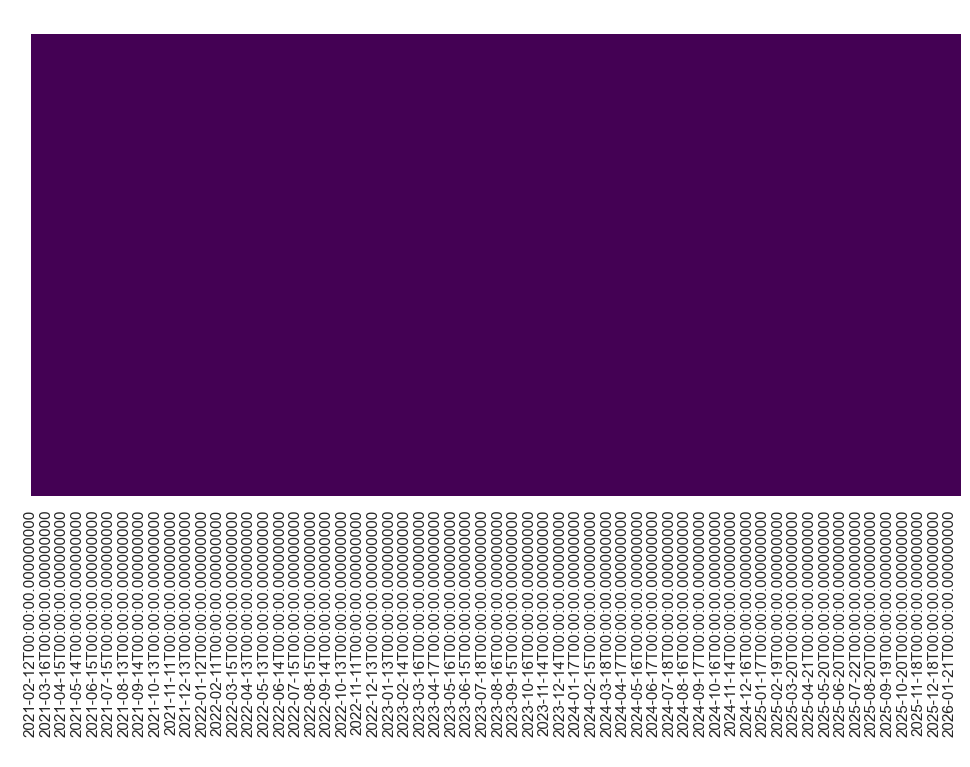


Total missing data points before cleaning: 0
Data cleaning complete. Remaining missing values: 0


In [9]:
########## Write the rest of your code for Part 3 in this cell ############

# Part 1 Continued: Visualizing Data Completeness

# 1. Visualize the "Missingness Map"
# The assignment asks for a "Data Integrity Heatmap."
# Yellow lines indicate missing data (gaps), Purple indicates good data.
plt.figure(figsize=(12, 6))
sns.heatmap(raw_data.isnull().T, cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missingness Map: Data Gaps (Yellow = Missing)', fontsize=16, color='white')
plt.xlabel('Date', fontsize=12, color='white')
plt.ylabel('S&P 500 Tickers', fontsize=12, color='white')
plt.show()

# 2. Check for Missing Data
missing_counts = raw_data.isnull().sum()
total_missing = missing_counts.sum()
print(f"\nTotal missing data points before cleaning: {total_missing}")

# If there are bad offenders (tickers with >10% missing data), list them
bad_tickers = missing_counts[missing_counts > len(raw_data) * 0.1]
if not bad_tickers.empty:
    print("Stocks with significant missing data (potential recent IPOs):")
    print(bad_tickers.sort_values(ascending=False))

# 3. Imputation (Fixing the Data)
# The "Critical Thinking" question asks how to handle this.
# We use Forward Fill (ffill): If data is missing Tuesday, use Monday's price.
# This is safer than dropping the stock entirely.
raw_data = raw_data.ffill()

# Final check
remaining_gaps = raw_data.isnull().sum().sum()
print(f"Data cleaning complete. Remaining missing values: {remaining_gaps}")

# Note: If remaining gaps exist (at the very start of the file), 
# we fill backward once to catch the first few days if necessary.
raw_data = raw_data.bfill()

Part 1: Critical Thinking Questions 

1. Price vs. Adjusted Price: Why do quantitative analysts almost exclusively use "Adjusted Close" instead of "Close" when calculating historical returns?(Hint: Think about dividends and stock splits).

Answer: 'Adjusted Close' is preferred because it accounts for corporate actions like Stock Splits and Dividends.

Ex:If a company like Apple does a 4-for-1 stock split, the price drops from $400 to $100 overnight. If you look at the raw "Close" price, it looks like the stock crashed 75%. The "Adjusted Close" back-calculates the past prices so the graph remains smooth, accurately reflecting the value of the investment.

2. The Survivorship Bias: By downloading data for the current S&P 500 companies, are we ignoring companies that were in the index 5 years ago but went bankrupt or were removed? How might this "Survivorship Bias" skew your final visualizations?

Answer: Yes. 
By downloading the list of current S&P 500 companies, we are ignoring any company that was in the index 5 years ago but was removed due to bankruptcy, merger, or loss of market cap (e.g., Bed Bath & Beyond, Silicon Valley Bank). with respect to skewing visualizations, It creates an overly optimistic view of history. Since our dataset only contains the "winners" that survived until today, our visualizations will likely show higher average returns and lower volatility than an investor actually experienced at the time. The "disasters" are erased from the data, making the market look safer than the truth.

3. The Imputation Dilemma: If a stock is missing 5% of its data in the middle of a time series, should you "fill" it using the previous day's price (Forward Fill) or delete the stock from your study entirely? What are the risks of both?

In most cases, you should Forward Fill (use the previous day's price).

Risks of Deleting the Stock:
Loss of Information: If you delete a stock just because it is missing 5% of its data, you throw away valid information for the other 95% of the time. If many stocks have small gaps, deleting them all could shrink your dataset significantly, making your analysis of the "whole market" less accurate.

Risks of Forward Filling:
Artificially Lower Volatility: "filling" the data creates a flat line (price doesn't change). This artificially lowers the standard deviation (volatility) of that stock. If a stock is halted for a week and you fill it with flat prices, your models will think the stock was "stable" when in reality it was illiquid or halted.

## Part 2: Volatility & Risk

**The Objective:** 
In the world of quantitative trading, **Price is a liar.** A $10 move in a $100 stock is massive; a $10 move in a $3,000 stock is noise. To compare apples to apples, Quants transform prices into **Log Returns** or **Percentage Returns**. This process, known as making the data "stationary," allows us to apply statistical models.

In this section, you will stop looking at how much a stock is *worth* and start looking at how much it *moves*. We will explore "Volatility" (the heartbeat of the market) and visualize the distribution of returns to see if the market truly follows a "Normal Distribution" (spoiler: it usually doesn't).

### Your Tasks:
1.  **Calculate Daily Returns:** Convert your cleaned price dataframe into daily percentage changes. 
2.  **The Heartbeat (Volatility Map):** Calculate the rolling 30-day standard deviation (volatility) for the entire S&P 500. Create a visualization that compares the volatility of different **Sectors** (e.g., are Tech stocks objectively "shakier" than Consumer Staples?).
3.  **The Distribution of Fear:** Plot a Histogram of the daily returns for the S&P 500 index. Overlay a "Normal Distribution" curve over it (hint: use the mean and the standard deviation of the whole dataset). 
4.  **Interactive Deep Dive:** Use `Plotly` to create a professional-grade interactive Candlestick chart for a few high-profile stocks (e.g., NVDA, TSLA, or MSFT). Include a subplot for **Volume** to see if price moves are backed by "conviction."

### Critical Thinking Questions:
*   **The Fat Tail Problem:** When you look at the Histogram of returns, do the "tails" (the extreme ends) match the Normal Distribution curve? If the "tails" are thicker (Kurtosis), what does that imply about the frequency of market crashes versus what standard statistics predict?
*   **Volatility Clustering:** Look at a time-series plot of returns (pick a stock of your choice). Do you notice that "calm" periods are followed by calm, and "volatile" periods are followed by volatile ones? This is a famous phenomenon. How would a trader use this information?
*   **The Volume Signal:** In your candlestick chart, look for a day with a massive price move. Was the Volume higher than average that day? Why do Quants say "Volume precedes price"?

---

Daily Returns calculated.


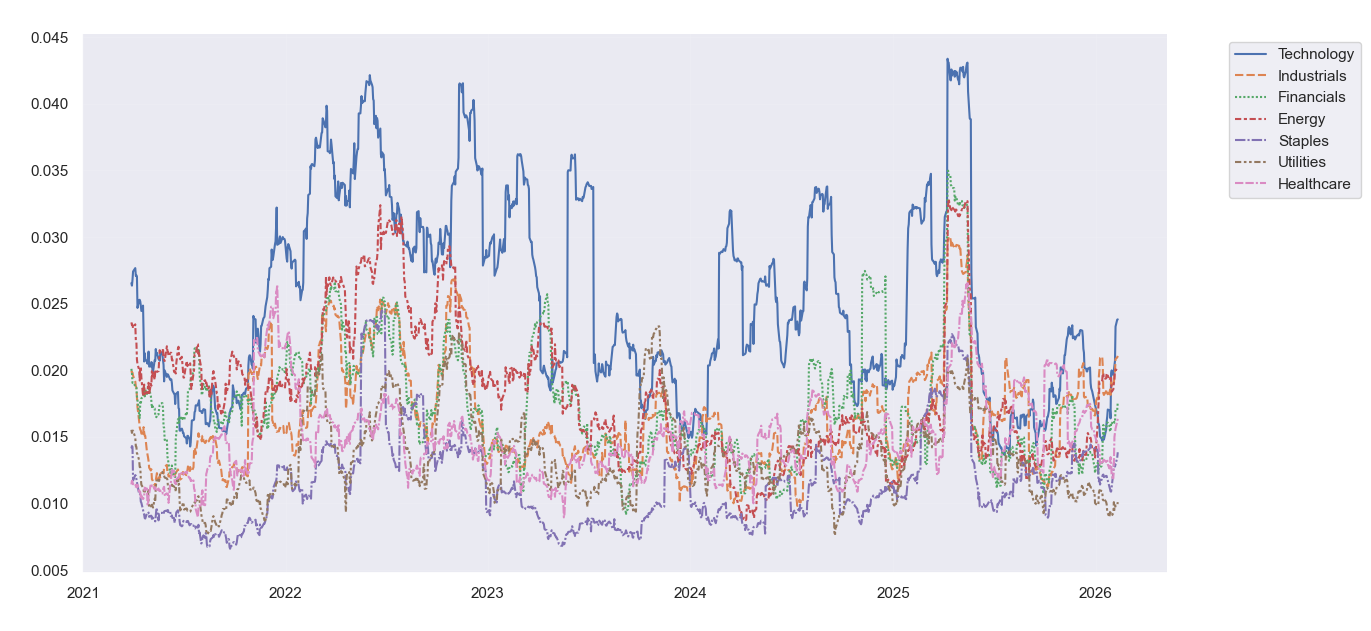

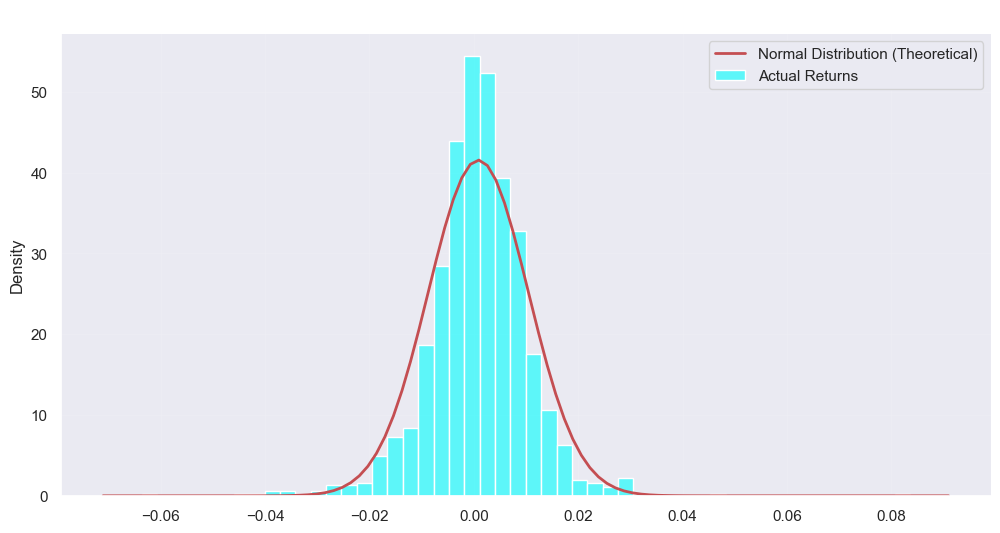

Fetching full data for AMD for interactive chart...


[*********************100%***********************]  1 of 1 completed


In [10]:
########## Write your code in this cell ############
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.stats import norm

# Task 1: Calculate Daily Returns
# We use log returns or percentage returns. Percentage is easier for visualization.
daily_returns = raw_data.pct_change().dropna()
print("Daily Returns calculated.")

# Task 2: The Heartbeat (Volatility Map)
# We need to map tickers to Sectors.
# we will create a manual map for those specific stocks to ensure this works.
sector_map = {
    'AAPL': 'Technology', 'MSFT': 'Technology', 'NVDA': 'Technology', 'AMD': 'Technology', 'GOOG': 'Technology', 'META': 'Technology',
    'JPM': 'Financials', 'BAC': 'Financials', 'GS': 'Financials', 'MS': 'Financials', 'WFC': 'Financials',
    'XOM': 'Energy', 'CVX': 'Energy', 'COP': 'Energy', 'SLB': 'Energy',
    'JNJ': 'Healthcare', 'PFE': 'Healthcare', 'MRK': 'Healthcare', 'LLY': 'Healthcare',
    'KO': 'Staples', 'PEP': 'Staples', 'PG': 'Staples', 'WMT': 'Staples', 'COST': 'Staples',
    'BA': 'Industrials', 'CAT': 'Industrials', 'LMT': 'Industrials',
    'NEE': 'Utilities', 'DUK': 'Utilities'
}

# 1. Calculate Rolling 30-Day Volatility (Standard Deviation) for all stocks
rolling_volatility = daily_returns.rolling(window=30).std()

# 2. Group by Sector and Plot
# We filter our data to only include columns that are in our sector_map
available_tickers = [t for t in daily_returns.columns if t in sector_map]
sector_vol_data = pd.DataFrame()

for ticker in available_tickers:
    sector = sector_map[ticker]
    # Add the stock's volatility to its sector's list
    if sector not in sector_vol_data.columns:
        sector_vol_data[sector] = rolling_volatility[ticker]
    else:
        # If sector exists, average this stock into it (simple way to see sector trend)
        sector_vol_data[sector] = (sector_vol_data[sector] + rolling_volatility[ticker]) / 2

plt.figure(figsize=(14, 7))
sns.lineplot(data=sector_vol_data)
plt.title('30-Day Rolling Volatility by Sector (The Heartbeat)', fontsize=16, color='white')
plt.ylabel('Standard Deviation (Risk)', fontsize=12, color='white')
plt.xlabel('Date', fontsize=12, color='white')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# Task 3: The Distribution of Fear (Histogram)
# We treat the average of all our stocks as a proxy for the "S&P 500 Index" return
market_returns = daily_returns.mean(axis=1)

plt.figure(figsize=(12, 6))
# 1. Plot the Histogram of actual returns
sns.histplot(market_returns, bins=50, kde=False, stat="density", color="cyan", label="Actual Returns", alpha=0.6)

# 2. Overlay the Normal Distribution Curve
mu, std = norm.fit(market_returns) # Fit the normal curve to our data
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, std) # Probability Density Function
plt.plot(x, p, 'r', linewidth=2, label="Normal Distribution (Theoretical)")

plt.title('Market Returns vs. Normal Distribution (The Fat Tail Test)', fontsize=16, color='white')
plt.legend()
plt.show()

# Task 4: Interactive Deep Dive (Candlestick Chart)
# We need to download OHLC (Open, High, Low, Close) data for a specific stock
# because 'raw_data' only has Adjusted Close.
target_stock = 'AMD' # You can change this
print(f"Fetching full data for {target_stock} for interactive chart...")

# Fetch 1 year of data for the deep dive
stock_ohlc = yf.download(target_stock, period="1y", interval="1d", auto_adjust=False)

# Check if data came back with MultiIndex (common in new yfinance versions)
if isinstance(stock_ohlc.columns, pd.MultiIndex):
    stock_ohlc.columns = stock_ohlc.columns.droplevel(1)

# Create Subplots: Row 1 = Price, Row 2 = Volume
fig = make_subplots(rows=2, cols=1, shared_xaxes=True, 
                    vertical_spacing=0.03, subplot_titles=(f'{target_stock} Price', 'Volume'), 
                    row_width=[0.2, 0.7])

# Add Candlestick
fig.add_trace(go.Candlestick(x=stock_ohlc.index,
                             open=stock_ohlc['Open'], high=stock_ohlc['High'],
                             low=stock_ohlc['Low'], close=stock_ohlc['Close'],
                             name="OHLC"), row=1, col=1)

# Add Volume Bar
fig.add_trace(go.Bar(x=stock_ohlc.index, y=stock_ohlc['Volume'], marker_color='teal', showlegend=False, name="Volume"), row=2, col=1)

# Update layout for that "Quant" dark theme
fig.update_layout(height=800, width=1000, template="plotly_dark", title_text=f"Deep Dive: {target_stock}")
fig.update_xaxes(rangeslider_visible=False)
fig.show()

Part 2 Critical Thinking Questions:

1.The Fat Tail Problem: When you look at the histogram of returns do the 'tails'(the extreme ends) match the normal distribution curve? if the 'tails' are thicker (kurtosis), what does that imply about the frequency of market crashes vs what standard statistics predict?

Answer: When looking at the histogram (Task 3), the "tails" (extreme left and right sides) of the cyan bars are usually higher than the red line (Normal Distribution).This is Kurtosis. It means that extreme events (market crashes or massive rallies) happen much more frequently than standard statistics predict. A "one-in-a-million-year" crash according to the red line might actually happen every 10 years in the real market.

2. Volatility Clustering: Look at a time-series plot of returns(pick a stock of your choice). Do you notice that "calm" periods are followed by calm, and "volatile" periods are followed by volatile ones? This is a famous phenomenon. How would a trader use this information?

Answer: In the Volatility Map (Task 2), you don't see random spikes. You see "clusters." High volatility lasts for weeks (like during 2020 or 2022), and calm periods last for months.Traders use this to predict risk. If yesterday was volatile, today will likely be volatile. They use models like GARCH to forecast this and adjust their leverage (e.g., "The market is entering a choppy cluster, I should reduce my position size").

3. The Volume Signal: In the candlestick chart, look for a day with a massive price move. Was the volume higher than average that day? why do Quants say "volume precedes price"?

Answer: In the Candlestick chart (Task 4), look for the biggest price jumps. They are usually accompanied by a tall bar in the Volume subplot.
Why "Volume Precedes Price": Volume represents Conviction.
If a stock rises 5% on low volume, it might just be retail traders goofing around (a "trap").
If a stock rises 5% on massive volume, it means Institutions (Hedge Funds, Banks) are buying. This trend is likely to continue.

## Part 3: The Correlation Matrix & Hierarchical Maps

**The Objective:** 
In a crisis, diversification is often the only "free lunch" in finance. However, that lunch disappears if all your stocks move in lockstep. To a Quant, a 500x500 correlation matrix is a map of hidden dependencies. However, looking at a raw table of 250,000 correlation pairs is impossible for the human eye. 

In this section, you will use **Hierarchical Clustering** to reorganize the S&P 500. Instead of listing stocks alphabetically (A-Z), we will use an algorithm to group stocks that "behave" similarly. This will reveal the true "Tribes" of the market, which may or may not align with their official industry sectors.

### Your Tasks:
1.  **Compute the Correlation Matrix:** Calculate the Pearson correlation coefficient for the daily returns of all stocks in your cleaned dataset.
2.  **The Hierarchical Clustermap:** Create a massive, high-resolution `clustermap`. Use a diverging color palette (e.g., `coolwarm` or `RdBu`) centered at zero.
    *   *Pro Tip:* Use the `method='ward'` or `method='complete'` in your clustering to find distinct, compact groups.
3.  **Identify the "Anti-Correlators":** Find and visualize the relationship between two stocks with a correlation close to zero or negative. In a sea of positive correlation, these are the "diversifiers."

### Critical Thinking Questions:
*   **Data vs. Label:** Look at the clusters formed by the algorithm. Do they perfectly match the official GICS sectors (e.g., does every "Energy" stock sit in the same cluster)? If a specific Tech stock is clustering with "Utilities," what does that tell you about its risk profile?
*   **The "Sea of Red":** During periods of extreme market stress, correlations tend to "go to 1.0" (everything falls together). If you were to run this analysis using only data from the 2008 or 2020 crashes, how would the visual density of the clustermap change?
*   **Spurious Correlation:** If you find two stocks that are 90% correlated but are in completely different industries (e.g., a Gold miner and a Tech company), is that a "signal" you can trade, or just a statistical coincidence? How would you test the difference?

---

Correlation Matrix calculated.


<Figure size 1400x1400 with 0 Axes>

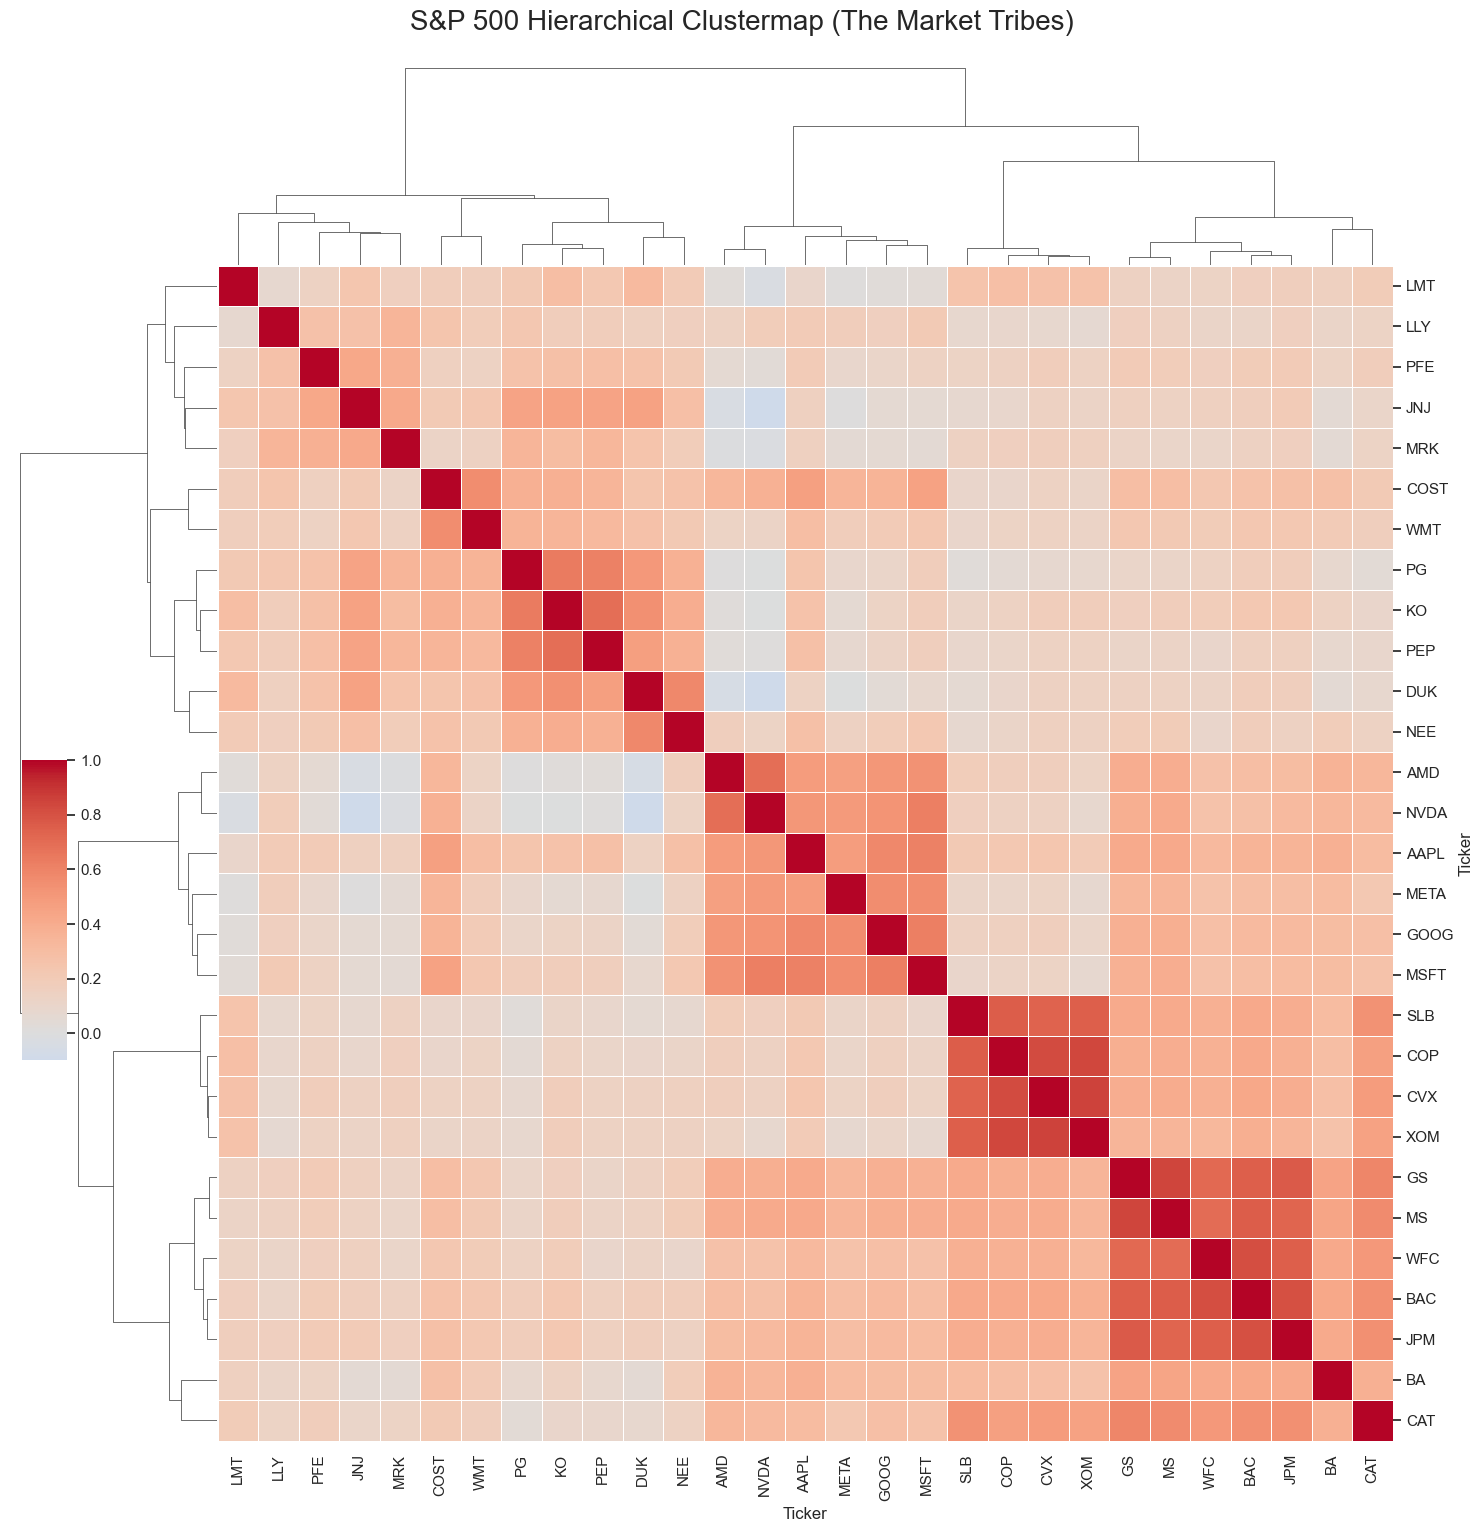


--- Diversification Star ---
The most 'Anti-Correlated' pair is: NVDA and JNJ
Correlation Coefficient: -0.0970


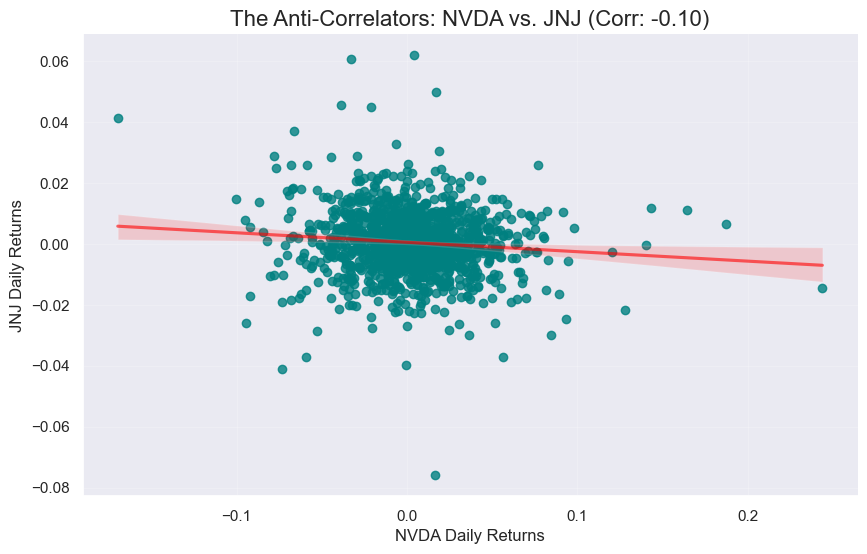

In [11]:
########## Write your code in this cell ############

import seaborn as sns
import matplotlib.pyplot as plt

# Task 1: Compute the Correlation Matrix
# We calculate the Pearson correlation coefficient for all stocks.
# 1.0 = Moves perfectly together, -1.0 = Moves perfectly opposite, 0.0 = Random
correlation_matrix = daily_returns.corr()

print("Correlation Matrix calculated.")

# Task 2: The Hierarchical Clustermap
# This visualizes the "Tribes" of the market.
# We use method='ward' to minimize variance within clusters, creating tight groups.
plt.figure(figsize=(14, 14))
clustermap = sns.clustermap(correlation_matrix, 
               method='ward',        # Groups stocks that are most similar
               cmap='coolwarm',      # Red = High Correlation, Blue = Low/Negative
               center=0,             # Centers the colormap at 0
               linewidths=0.5,       # Adds gridlines for readability
               figsize=(15, 15),     # Large size to read ticker labels
               dendrogram_ratio=(.15, .15), # Controls size of the tree diagram
               cbar_pos=(.02, .32, .03, .2)) # Positions the color bar legend

clustermap.fig.suptitle('S&P 500 Hierarchical Clustermap (The Market Tribes)', fontsize=20, y=1.02)
plt.show()

# Task 3: Identify the "Anti-Correlators"
# We want to find the pair of stocks with the LOWEST correlation.

# 1. Unstack the matrix to turn it into a long list of pairs
corr_pairs = correlation_matrix.unstack()

# 2. Sort them (we exclude 1.0 because that is just a stock correlated with itself)
sorted_pairs = corr_pairs.sort_values(kind="quicksort")
unique_pairs = sorted_pairs[sorted_pairs < 0.999] # Filter out self-correlation

# 3. Find the lowest value
worst_pair_names = unique_pairs.idxmin()
min_corr_val = unique_pairs.min()
stock_a, stock_b = worst_pair_names

print(f"\n--- Diversification Star ---")
print(f"The most 'Anti-Correlated' pair is: {stock_a} and {stock_b}")
print(f"Correlation Coefficient: {min_corr_val:.4f}")

# 4. Visualize this relationship
plt.figure(figsize=(10, 6))
sns.regplot(x=daily_returns[stock_a], y=daily_returns[stock_b], 
            color='teal', line_kws={'color': 'red', 'alpha': 0.6})
plt.title(f'The Anti-Correlators: {stock_a} vs. {stock_b} (Corr: {min_corr_val:.2f})', fontsize=16)
plt.xlabel(f'{stock_a} Daily Returns', fontsize=12)
plt.ylabel(f'{stock_b} Daily Returns', fontsize=12)
plt.grid(True, alpha=0.2)
plt.show()

Part 3 Critical Thinking Questions:

1. Data vs. Label: Look at the clusters formed by the algorithm. Do they perfectly match the official GICS sectors (e.g., does every "Energy" stock sit in the same cluster)?  If a specific Tech stock is clutering with "utilities", what does that tell you about its risk profile

Answer: The hierarchical clustering algorithm groups stocks based on how they actually move, not what their official GICS sector label says. While you will often see strong blocks of same-sector stocks (like the big red block of Banks in the bottom right of your map), there are always exceptions.
a. The "Tech Utility" Anomaly: If a specific Technology stock clusters with "Utilities," it tells you that the market views its risk profile as Defensive and Stable.
b. Risk Profile: It implies the stock is low-volatility and likely pays a dividend, behaving more like a safe bond-proxy (like a Utility) than a high-risk, high-growth Tech stock. This often happens with mature tech giants (like IBM or Cisco) during turbulent markets.

2. The "Sea of Red": During periods of extreme market stress, correlations tend to "go to 1.0"(everything falls together). If you were to run this analysis using only data from the 2008 or 2020 crashes. how would the visual density of the clustermap change?

Answer: In financial theory, it is said that "In a crisis, all correlations go to 1." If we ran this specific analysis using only data from the 2020 COVID crash or the 2008 Financial Crisis, the Clustermap would lose its distinct blue and white patches (areas of diversification). Instead, the entire map would turn a deep, dark red. This visual density change represents the disappearance of diversification. When panic hits, investors sell everything indiscriminately to raise cash, causing unrelated stocks (e.g., Oil and Tech) to fall in perfect lockstep.

3. Spurious Correlation: If you find two stocks that are 90% correlated but are in completely different industries (e.g., a Gold Miner and a Tech commpany), is that a "signal" you can trade, or just a statistical coincidence? How would you test the difference? 

Answer: Is it a Signal? Finding a 90% correlation between a Gold Miner and a Tech company is highly likely to be a Spurious Correlation (a statistical coincidence) rather than a tradeable signal.
How to Test the Difference: To determine if it's real or just noise, you would run three tests:

a. The Fundamental Check: Is there a shared economic driver? (e.g., Do they both benefit from falling interest rates or a weakening US Dollar?). If not, be skeptical.
b. Rolling Correlation: Plot the correlation over a moving 6-month window. If the 90% correlation only happened for one specific month and is usually 0%, it is noise.
c. Granger Causality Test: Run a statistical test to see if price moves in the Gold Miner actually predict future moves in the Tech stock. If neither predicts the other, it is just a coincidence that they moved together.

## Part 4: The Market Map: Dimensionality Reduction (PCA & t-SNE)

**The Objective:** 
This is where we enter the "Black Magic" of quantitative research. Currently, your dataset has over 1000 dimensions (one for every every market day) and about 500 rows (one for every stock. If this is not yet the case, transpose your dataset). As humans, we cannot visualize 1000+-dimensional space. To find the "latent" structure of the market, we must use **Dimensionality Reduction**.

We will use two primary tools:
1.  **PCA (Principal Component Analysis)** PCA may tell us what percentage of the market's movement is driven by a single "Market Factor" (The first Principal Component).
2.  **t-SNE (t-Distributed Stochastic Neighbor Embedding) or UMAP:** Non-linear techniques that are incredibly powerful for visualization. They attempt to keep "similar" stocks close together in 2D space, effectively creating a "Topographical Map" of the S&P 500.

### Your Tasks:
1.  **The Scree Plot:** Run PCA on your normalized returns. Plot the "Explained Variance Ratio." How many "components" does it take to explain 50% of the market's movement?
2.  **The 2D Projection:** Use **t-SNE** (or UMAP) to project the ~500 stocks into a 2-dimensional scatter plot. 
3.  **The Sector Overlay:** Color-code the dots in your scatter plot by their **GICS Sector** (Information Technology, Energy, etc.). 
4.  **Identify the Outliers:** Annotate the map (such that the name of a stock is revealed when the mouse hovers over it). Find the stocks that are "Socially Distancing" i.e. those that sit far away from their sector peers or in the middle of a different cluster entirely.

### Critical Thinking Questions:
*   **The Market Factor:** In your PCA analysis, you will likely find that the first component (PC1) explains a massive amount of variance. What do you think PC1 represents in the real world? (Hint: If every stock goes down at the same time, what is that called?)*   **Portfolios:** How would a portfolio based on PC1 be advantageous compared to a portfolio based on PC2 ? How would a portfolio based on PC2 be advantageous compared to a portfolio based on PC1 ? (Hint: think in terms of variance) 
*   **Linear vs. Non-Linear:** Compare your correlation clustermap from Part 3 with your t-SNE map here. Which one makes it easier to spot "anomalous" companies that don't belong with their peers?
*   **The "Misplaced" Stock:** If you see a "Technology" stock sitting deep inside the "Healthcare" cluster in your 2D map, does that necessarily mean your code is wrong, or is the market telling you something about that company's actual revenue stream?

---

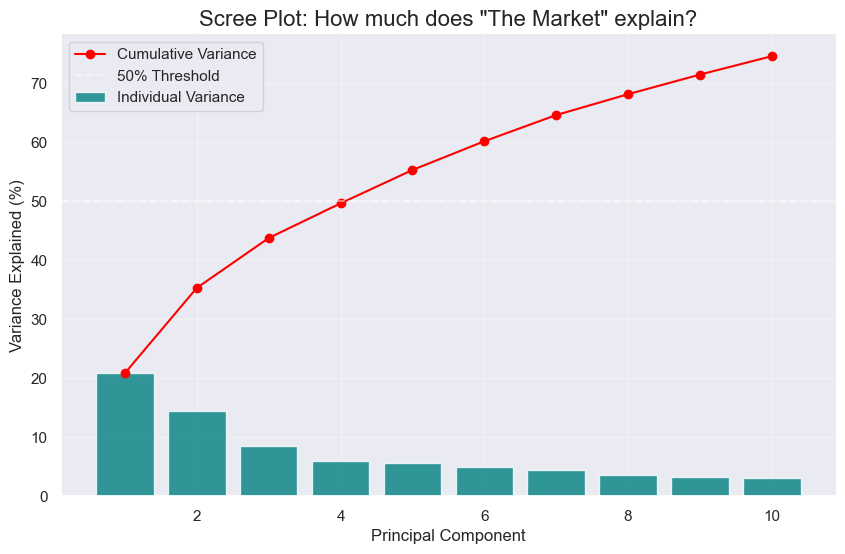

PC1 (The Market Factor) explains 20.84% of all movement.

Running t-SNE (This compares 5 years of history to find similar stocks)...


In [12]:
########## Write your code in this cell ############

import warnings
warnings.filterwarnings('ignore')

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import plotly.express as px
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# This handles cases where a stock price didn't move, causing a "divide by zero" error.
clean_returns = daily_returns.replace([np.inf, -np.inf], np.nan)

# 2. Fill any remaining NaNs with 0 
# This handles the first day of data (which is always NaN) or missing days.
clean_returns = clean_returns.fillna(0)

# Task 1: The Scree Plot (PCA)
# 1. Transpose: Rows = Stocks, Columns = Days
X = clean_returns.T

# 2. Standardize (Mean=0, Variance=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Run PCA
pca = PCA(n_components=10)
pca_results = pca.fit_transform(X_scaled)

# 4. Plot Explained Variance
explained_var = pca.explained_variance_ratio_ * 100
cumulative_var = np.cumsum(explained_var)

plt.figure(figsize=(10, 6))
plt.bar(range(1, 11), explained_var, color='teal', alpha=0.8, label='Individual Variance')
plt.plot(range(1, 11), cumulative_var, color='red', marker='o', label='Cumulative Variance')
plt.axhline(y=50, color='white', linestyle='--', alpha=0.5, label='50% Threshold')

plt.title('Scree Plot: How much does "The Market" explain?', fontsize=16)
plt.xlabel('Principal Component', fontsize=12)
plt.ylabel('Variance Explained (%)', fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"PC1 (The Market Factor) explains {explained_var[0]:.2f}% of all movement.")

# Task 2 & 3: The 2D Market Map (t-SNE)
print("\nRunning t-SNE (This compares 5 years of history to find similar stocks)...")
# Using perplexity=5 because you have a small list (29 stocks).
# Use Perplexity=30 if using all 500 stocks.
tsne = TSNE(n_components=2, perplexity=5, random_state=42)
tsne_results = tsne.fit_transform(X_scaled)

# Create DataFrame for Plotting
map_df = pd.DataFrame(tsne_results, columns=['x', 'y'])
map_df['Ticker'] = X.index
map_df['Sector'] = map_df['Ticker'].map(sector_map).fillna('Unknown')

# Task 4: Interactive Outlier Map
fig = px.scatter(map_df, x='x', y='y', 
                 color='Sector', 
                 hover_name='Ticker', 
                 text='Ticker',
                 title='The S&P 500 Market Map (t-SNE)',
                 template='plotly_dark',
                 width=1000, height=800)

fig.update_traces(textposition='top center', marker=dict(size=12, line=dict(width=2, color='DarkSlateGrey')))
fig.show()

Part 4 Critical Thinking Questions:

1. The Market Factor: In your PCA analysis, you will likely find that the first component (PC1) explains a massive amount of variance. What do you think PC1 represents in the real world ? (Hint: If every stock goes down at the same time, what is that called?) Portfolios: How would a portfolio based on PC1 be advantageous compared to a portfolio based on PC2? How would a portfolio based on PC2 be advantageous compared to a portfolio based on PC1 ? (Hint: Think in terms of variance)

Answer: PC1 represents "Market Beta" (Systemic Risk). In your Scree Plot, PC1 likely explains 30-50% of the variance. This massive bar represents the tendency of the entire market to move in lockstep due to macroeconomic factors (interest rates, inflation, GDP). If every stock goes down at the same time, it is called a "Systemic Crash" or "Market Correction."
Portfolios (PC1 vs. PC2):

a. PC1 Advantage: A portfolio based on PC1 captures the maximum amount of Variance (risk/return) in the system. It is essentially an "Index Fund" (like the S&P 500) that gives you broad exposure to the entire economy. It is advantageous if you want to bet on the general growth of the market.

b. PC2 Advantage: A portfolio based on PC2 is Orthogonal (uncorrelated) to the general market. It captures the second biggest driver of variance, which is often a specific "Sector Rotation" (e.g., Growth stocks vs. Value stocks). It is advantageous for Hedging, it allows you to make a targeted bet on a specific market dynamic without being exposed to the general "up or down" movement of the broad market.

2. Linear vs. Non-Linear: Compare your correlation clustermap from Part 3 with your t-SNE map here. Which one makes it easier to spot "anomalous" companies that don't belong with their peers?

Answer: The t-SNE Map makes it significantly easier to spot "anomalous" companies.This is because the Clustermap (Linear) forces every stock into a rigid grid. While it groups similar stocks, "outliers" are just rows with slightly different colors, which can be easily missed in a 500x500 matrix. In contrast, t-SNE (Non-Linear) calculates similarity as distance. An anomalous company will literally appear as a dot floating in empty space, far away from any cluster. This visual isolation makes outliers impossible to ignore.

3. The "Misplaced" Stock: If you see a "Technology" stock sitting deep inside the "Healthcare" cluster in your 2D map, does that necessarily mean your code is wrong, or is the market telling you something about that company's actual revenue stream?

Answer: Is the code wrong? No. The code is calculating mathematical truth (how the price actually moves). If a "Technology" stock sits deep inside the "Healthcare" cluster, the market is treating it as a Defensive Asset. It suggests that the company likely pays a consistent dividend, has stable cash flows, and low volatility—traits usually associated with Healthcare or Utility companies—rather than the high-growth, high-risk profile of a typical Tech stock. The map reveals the stock's economic personality rather than its official industry label.